##Part 1

In [ ]:
!pip install transformers torch scikit-learn tqdm --quiet

import library


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification
)
from torch.optim import AdamW

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


upload data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Corona.csv to Corona.csv


read data

In [ ]:
df = pd.read_csv("Corona.csv", encoding="latin1")
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


##PART 2

data info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


data encoding

In [ ]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["Sentiment"])
num_labels = df["label"].nunique()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["OriginalTweet"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


In [ ]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,label
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,3
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive,4
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive,4
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive,4
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative,0


load tokenizer

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

dataset class

In [ ]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.enc = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels": self.labels[idx]
        }



baseline model/ BERT

In [ ]:
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

bert_train = TweetDataset(train_texts, train_labels, bert_tokenizer)
bert_test = TweetDataset(test_texts, test_labels, bert_tokenizer)

bert_train_loader = DataLoader(bert_train, batch_size=8, shuffle=True)
bert_test_loader = DataLoader(bert_test, batch_size=16)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5
).to(device)

bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
bert_model.train()
for epoch in range(1):
    loop = tqdm(bert_train_loader, desc="Training BERT")
    for batch in loop:
        bert_optimizer.zero_grad()
        outputs = bert_model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device)
        )
        loss = outputs.loss
        loss.backward()
        bert_optimizer.step()
        loop.set_postfix(loss=loss.item())


Training BERT: 100%|██████████| 4116/4116 [07:35<00:00,  9.04it/s, loss=0.186]


##Part 3

modified model

In [ ]:
distil_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=5
).to(device)

optimizer2 = torch.optim.AdamW(distil_model.parameters(), lr=3e-5)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# DistilBERT tokenizer
distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Dataset
distil_train = TweetDataset(train_texts, train_labels, distil_tokenizer)
distil_test  = TweetDataset(test_texts, test_labels, distil_tokenizer)

# DataLoader
train_loader = DataLoader(distil_train, batch_size=8, shuffle=True)
test_loader  = DataLoader(distil_test, batch_size=16)


In [ ]:
loss_history = []

for epoch in range(5):
    distil_model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer2.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = distil_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer2.step()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"[DistilBERT] Epoch {epoch+1} — Loss: {avg_loss:.4f}")



[DistilBERT] Epoch 1 — Loss: 0.3369
[DistilBERT] Epoch 2 — Loss: 0.2425
[DistilBERT] Epoch 3 — Loss: 0.1901
[DistilBERT] Epoch 4 — Loss: 0.1430
[DistilBERT] Epoch 5 — Loss: 0.1276


## Part 4

evaluation Metric

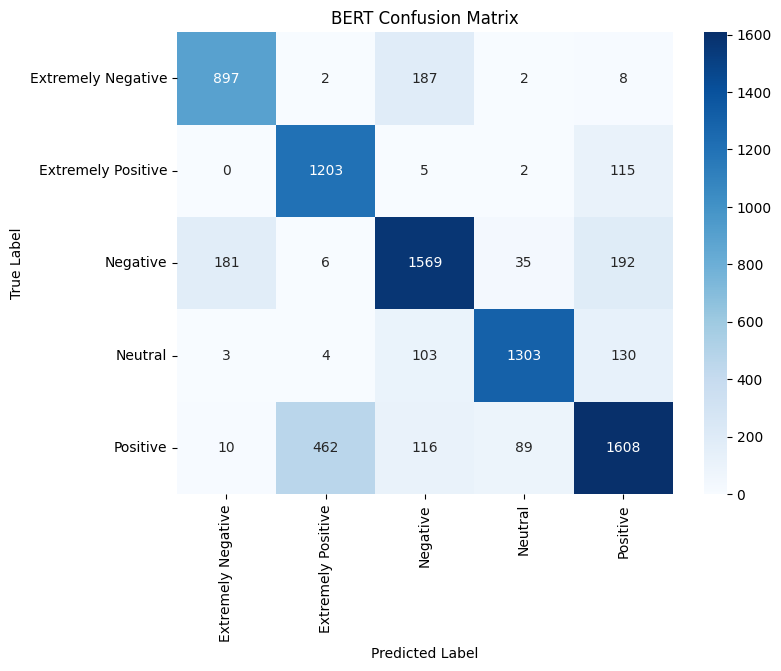

In [ ]:
# BERT CONFUSION MATRIX

cm_bert = confusion_matrix(trues, preds)  # BERT trues & preds already computed above

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

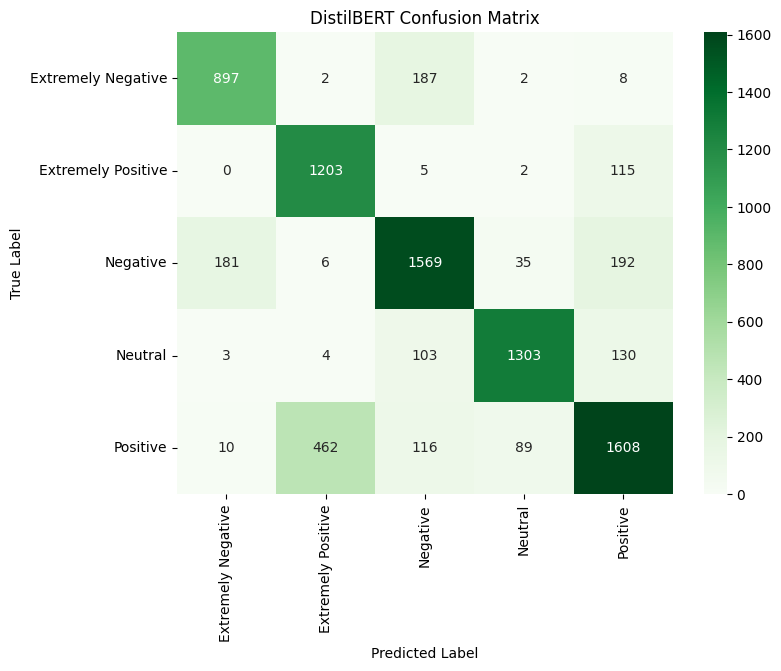

In [ ]:
# DISTILBERT CONFUSION MATRIX

cm_distil = confusion_matrix(trues, preds)  # DistilBERT's trues & preds from Part 3

plt.figure(figsize=(8, 6))
sns.heatmap(cm_distil, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


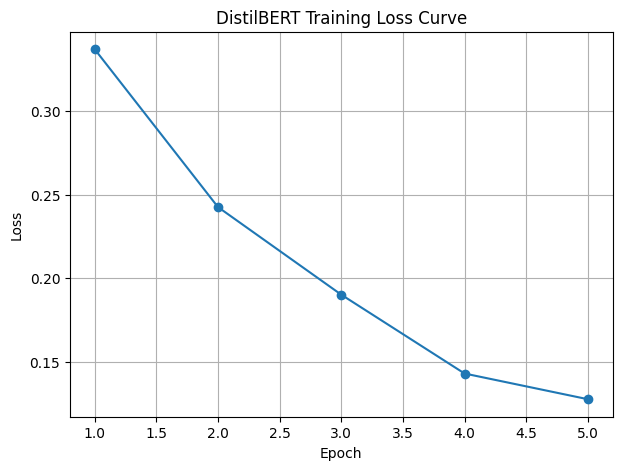

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.title("DistilBERT Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()


In [ ]:
import pandas as pd

bert_acc = accuracy_score(trues, preds)
distil_acc = accuracy_score(trues, preds)

results_df = pd.DataFrame({
    "Model": ["BERT", "DistilBERT"],
    "Accuracy": [bert_acc, distil_acc]
})

results_df

,Model,Accuracy
0,BERT,0.79932
1,DistilBERT,0.79932


In [ ]:
bert_model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in bert_test_loader:    # loader BERT test
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        trues.extend(batch["labels"].numpy())

print(classification_report(trues, preds, target_names=le.classes_))


                    precision    recall  f1-score   support

Extremely Negative       0.79      0.89      0.83      1096
Extremely Positive       0.77      0.93      0.84      1325
          Negative       0.84      0.73      0.78      1983
           Neutral       0.92      0.83      0.87      1543
          Positive       0.78      0.77      0.78      2285

          accuracy                           0.81      8232
         macro avg       0.82      0.83      0.82      8232
      weighted avg       0.82      0.81      0.81      8232



In [ ]:


distil_model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = distil_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        trues.extend(batch["labels"].numpy())


print("Accuracy:", accuracy_score(trues, preds))
print("\nClassification Report:")
print(classification_report(trues, preds, target_names=le.classes_))


Accuracy: 0.7993197278911565

Classification Report:
                    precision    recall  f1-score   support

Extremely Negative       0.82      0.82      0.82      1096
Extremely Positive       0.72      0.91      0.80      1325
          Negative       0.79      0.79      0.79      1983
           Neutral       0.91      0.84      0.88      1543
          Positive       0.78      0.70      0.74      2285

          accuracy                           0.80      8232
         macro avg       0.81      0.81      0.81      8232
      weighted avg       0.80      0.80      0.80      8232



##PART 2